# WDM_MUX4 -- Cascaded-MZI Binary-Tree Demultiplexer (N=2 / N=4, Ideal + Real-FDTD + GDS)

This notebook is the complete, consolidated design record for the 4-channel
WDM demultiplexer built from the cascaded-MZI **binary-tree** ("Mux4")
topology -- see Luceda Photonics'
[`muxN` tutorial](https://academy.lucedaphotonics.com/training/topical_training/wdm_transmitter_mzi/muxn).
It reuses `wdm_sax.ipynb`'s single-stage lattice filter as its building block,
one stage per tree node, and follows the same 7-section structure as that
notebook.

**Do not use "Run All."** Stop and look at each plot before trusting the next
step.

## 1. Introduction

The tree: one **stage 1** lattice splits the input into an "up"/"down" branch,
and one **stage 2** lattice per branch (`stage2_up`, `stage2_down`) splits
each branch again, giving 4 simultaneous wavelength-channel outputs
(`ch1`..`ch4`). This is a **different topology** from `wdm_sax.ipynb`'s
cascaded lattice filter (N couplers sharing one `delta_L_um`, synthesized for
a single maximally-flat passband) -- a lattice produces one flat-top
passband; this tree produces 4 *separate* channel outputs from a single
input, with each tree node an instance of `wdm_sax.ipynb`'s own lattice
building block.

This notebook builds and compares the tree at **both $N=2$** (each node a
plain 2-coupler MZI) **and $N=4$** (each node a maximally-flat halfband
lattice), for both the ideal/analytic model and the real-FDTD-measured model.
The GDS physical layout (Section 6) covers **N=4 only** -- the real-FDTD
comparison (Section 5) shows N=4 substantially more tolerant of a real,
unavoidable phase-calibration residual in the delay arm (real worst-channel
extinction improves from 1.7dB at N=2 to 10.1dB at N=4), so N=4 is the design
carried forward to a physical layout.

## 2. Circuit design with SAX -- analytical model (N=2, N=4)

**Round-trip phase.** Every lattice stage's transmission depends on the phase
difference accumulated between its two arms over a path-length difference
$\Delta L$:
$$
\phi(\lambda) = \frac{2\pi\, n_{\mathrm{eff}}(\lambda)\, \Delta L}{\lambda}.
$$

**Free spectral range.**
$$
\mathrm{FSR} = \frac{\lambda_0^2}{n_g \cdot \Delta L}.
$$

**Binary-tree FSR-halving.** Stage 2 must resolve 2 channels inside each of
stage 1's own 2 outputs, so stage 2's FSR must be exactly half of stage 1's:
$$
\Delta L_1 = 2\, \Delta L_2 \quad\Longleftrightarrow\quad \mathrm{FSR}_2 = 2\cdot\mathrm{FSR}_1.
$$

**Maximally-flat (halfband) coupler synthesis, N=4** (per stage). Same target
as `wdm_sax.ipynb` Section 2:
$$
|A(\phi)|^2 = P_K\!\left(\sin^2\tfrac{\phi}{2}\right), \qquad
P_K(x)=\sum_{k=K}^{2K-1}\binom{2K-1}{k}x^k(1-x)^{2K-1-k}, \qquad N=2K,
$$
$P_2(x)=3x^2-2x^3$ for $N=4$.

**The quarter-wave correction.** Feeding stage 1's bar output directly into an
*identically-parameterized* stage 2 does not work: stage 1's bar-output
envelope peaks exactly where an identical stage 2 sits at its own ambiguous
50/50 crossover (not an extremum), degenerating that branch's 2 channels into
a capped double-peak. The fix is a genuine extra length increment on
`stage2_up`'s own arm, set to add exactly a quarter-FSR ($\pi/2$) of
differential phase at $\lambda_0$:
$$
\frac{2\pi\, n_{\mathrm{eff},0}\, \Delta}{\lambda_0} = \frac{\pi}{2}
\quad\Longrightarrow\quad
\Delta = \frac{\lambda_0}{4\, n_{\mathrm{eff},0}}.
$$
This is `mux4_tree.quarter_wave_length_um` -- a universal constant,
independent of whatever base $\Delta L$ it is added on top of, and applies
identically whether each stage is $N=2$ or $N=4$.

In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import sax
from scipy.signal import find_peaks

from pic_toolkit import style
from pic_toolkit.circuits import mzi_lattice as ml
from pic_toolkit.circuits import mux4_tree as mt

style.apply_style()
%matplotlib inline

# ============================================================
# Design parameters (shared by every section below)
# ============================================================
WL0_UM = 1.35          # design center wavelength -- this toolkit's convention
N_EFF0 = 2.4085        # phase index at WL0_UM, from 07_mzi.ipynb's MPB arm dispersion
N_G0 = 2.763           # group index at WL0_UM, from 07_mzi.ipynb's FDTD FSR-fit

DELTA_L_1_UM = 15.0    # stage 1 -- 07_mzi.ipynb's own reference sweep point
DELTA_L_2_DOWN_UM = 7.5  # stage 2 ("down") -- delta_L_1 = 2*delta_L_2

QUARTER_WAVE_UM = mt.quarter_wave_length_um(N_EFF0, WL0_UM)          # lambda0/(4*n_eff0)
DELTA_L_2_UP_UM = DELTA_L_2_DOWN_UM + QUARTER_WAVE_UM                # stage 2 ("up")

fsr1_nm = ml.delta_L_um_to_fsr(DELTA_L_1_UM, WL0_UM, N_G0) * 1000
fsr2_nm = ml.delta_L_um_to_fsr(DELTA_L_2_DOWN_UM, WL0_UM, N_G0) * 1000
kappas4, signs4 = ml.synthesize_maximally_flat_kappas(4)

print(f"quarter-wave correction length = {QUARTER_WAVE_UM * 1000:.4f} nm")
print(f"delta_L_1(stage1)       = {DELTA_L_1_UM} um  ->  FSR_1 = {fsr1_nm:.2f} nm")
print(f"delta_L_2(stage2_down)  = {DELTA_L_2_DOWN_UM} um  ->  FSR_2 = {fsr2_nm:.2f} nm (should be ~2x FSR_1)")
print(f"delta_L_2(stage2_up)    = {DELTA_L_2_UP_UM:.7f} um  (= delta_L_2_down + quarter-wave correction)")
print(f"N=4 halfband kappas: {np.round(kappas4, 4)}  signs: {signs4}")

# One shared wavelength grid, reused by every ideal AND real circuit built below.
wl_sweep = jnp.linspace(1.30, 1.40, 4000)
wl_np = np.asarray(wl_sweep)

/home/yuma/miniconda3/envs/mp/lib/python3.10/site-packages/sax/backends/__init__.py:78: UserWarning: klujax not found. Please install klujax for better performance during circuit evaluation!
  warnings.warn(


quarter-wave correction length = 140.1287 nm
delta_L_1(stage1)       = 15.0 um  ->  FSR_1 = 43.97 nm
delta_L_2(stage2_down)  = 7.5 um  ->  FSR_2 = 87.95 nm (should be ~2x FSR_1)
delta_L_2(stage2_up)    = 7.6401287 um  (= delta_L_2_down + quarter-wave correction)
N=4 halfband kappas: [0.9328 0.     0.7503 0.5006]  signs: [1, 1, 1, -1]


### N=2 -- ideal tree (each node a plain 2-coupler MZI)

Every stage in this tree is an **ordinary 50:50 MZI** -- `kappas=[0.5, 0.5],
signs=[1, 1]`, i.e. `mzi_lattice.py`'s own trivial N=2 case
(`build_lattice_circuit`), reused three times (once per stage instance). No
lattice synthesis is needed anywhere here -- each stage's job is a simple
sinusoidal 2-way split, not a flat-top passband.
`pic_toolkit.circuits.mux4_tree.build_mux4_tree_circuit` wires 3 stage
circuits into the binary tree: `in_top` excites stage1, whose
`out_top`/`out_bot` feed `stage2_up`/`stage2_down`'s own `in_top`, and each
stage2's `out_top`/`out_bot` become 2 of the 4 final channels (`ch1`, `ch2`
from `stage2_up`; `ch3`, `ch4` from `stage2_down`).

stage1 (N=2) alone @ wl0=1.35um: bar=0.4651 cross=0.5349 sum=1.0000 (should be close to 1 -- lossless)


total power across sweep: [0.9999994, 1.0000002] (should be ~1.0 -- lossless)


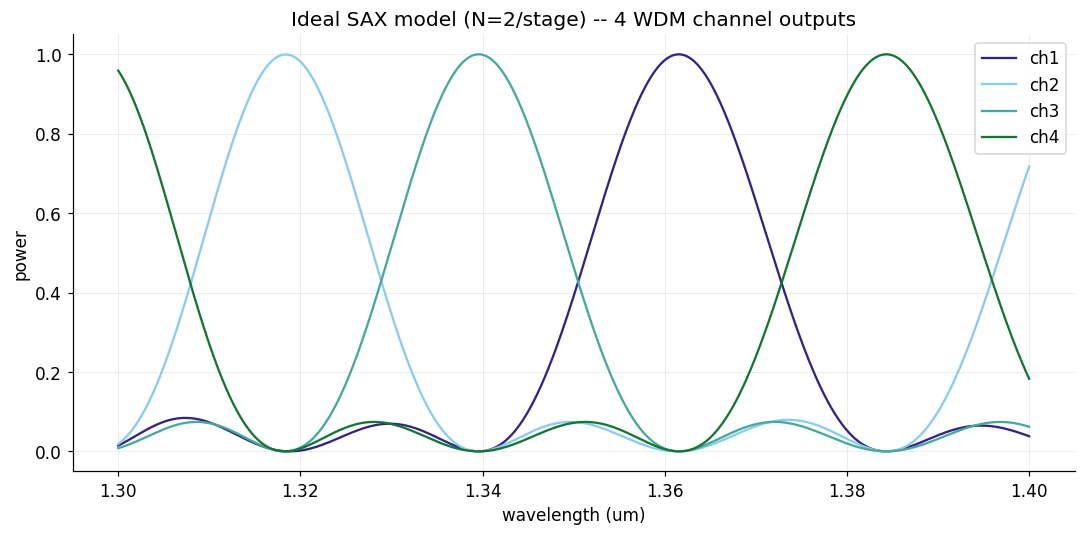

In [2]:
kappas2, signs2 = [0.5, 0.5], [1, 1]
stage1_n2_fn, _ = ml.build_lattice_circuit(kappas2, signs2, DELTA_L_1_UM, N_EFF0, N_G0, WL0_UM)

S1 = stage1_n2_fn(wl=WL0_UM)
bar1 = abs(S1[("in_top", "out_top")]) ** 2
cross1 = abs(S1[("in_top", "out_bot")]) ** 2
print(f"stage1 (N=2) alone @ wl0={WL0_UM}um: bar={bar1:.4f} cross={cross1:.4f} sum={bar1 + cross1:.4f} "
      f"(should be close to 1 -- lossless)")

circuit_n2_ideal, _ = mt.build_ideal_mux4_tree_circuit(
    DELTA_L_1_UM, DELTA_L_2_DOWN_UM, N_EFF0, N_G0, WL0_UM, quarter_wave_shift_up=True, n_couplers=2,
)
S_n2 = circuit_n2_ideal(wl=wl_sweep)
chans_n2_ideal = {ch: np.abs(np.asarray(S_n2[("in_top", ch)])) ** 2 for ch in ("ch1", "ch2", "ch3", "ch4")}
total_n2_ideal = sum(chans_n2_ideal.values())
print(f"total power across sweep: [{np.min(total_n2_ideal):.7f}, {np.max(total_n2_ideal):.7f}] (should be ~1.0 -- lossless)")

fig, ax = plt.subplots(figsize=(10, 5))
for (ch, p), color in zip(chans_n2_ideal.items(), style.COLOR_CYCLE):
    ax.plot(wl_np, p, color=color, label=ch)
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("power")
ax.set_title("Ideal SAX model (N=2/stage) -- 4 WDM channel outputs")
ax.legend()
fig.tight_layout()
plt.show()

**Channel peaks and extinction (N=2 ideal).** For each channel, find its own
transmission peak (wavelength + power), then measure extinction against the
*strongest other channel* at that same wavelength -- the relevant crosstalk
figure for a WDM demux.

In [3]:
def peak_and_extinction_table(chans, wl_np):
    peak_info = {}
    for ch, p in chans.items():
        peaks, _ = find_peaks(p, prominence=0.1)
        peak_wls, peak_powers = wl_np[peaks], p[peaks]
        i_best = int(np.argmax(peak_powers))
        peak_info[ch] = (float(peak_wls[i_best]), float(peak_powers[i_best]))

    print(f"{'channel':8s} {'peak wl (um)':>13s} {'peak power':>11s} {'extinction (dB)':>16s}")
    for ch in ("ch1", "ch2", "ch3", "ch4"):
        peak_wl, peak_pw = peak_info[ch]
        idx = int(np.argmin(np.abs(wl_np - peak_wl)))
        worst_other = max(chans[other][idx] for other in ("ch1", "ch2", "ch3", "ch4") if other != ch)
        ext_db = 10 * np.log10(peak_pw / max(worst_other, 1e-12))
        print(f"{ch:8s} {peak_wl:13.4f} {peak_pw:11.4f} {ext_db:16.1f}")
    return peak_info


peak_info_n2_ideal = peak_and_extinction_table(chans_n2_ideal, wl_np)
channel_spacing_nm = np.diff(sorted(v[0] for v in peak_info_n2_ideal.values())) * 1000
print(f"\nchannel spacing (nm): {np.round(channel_spacing_nm, 2)}")

channel   peak wl (um)  peak power  extinction (dB)
ch1             1.3615      1.0000             44.1
ch2             1.3184      0.9996             35.1
ch3             1.3396      1.0000             67.0
ch4             1.3843      1.0000             84.7

channel spacing (nm): [21.21 21.96 22.78]


**Why the quarter-wave correction is needed (N=2).** Naively giving
`stage2_up` and `stage2_down` the **same** `delta_L_2` (simply half of
`delta_L_1`, per the standard FSR-halving rule) does **not** give 4 clean
channels. Stage 1 splits its input into a bar output (`out_top`) and a cross
output (`out_bot`) that are $90°$ out of phase with each other (a lossless
coupler's cross port always picks up a $\pm90°$ phase relative to its bar
port). Stage 1's bar-output envelope reaches its own peak transmission
exactly where an *identically-parameterized* stage 2 sits at its own
ambiguous 50/50 crossover point (not at an extremum) -- so the "up" branch's
two channels come out as degenerate double peaks, each capped well below full
power. The "down" branch (fed by stage 1's cross output, already $90°$
offset) does not have this problem.

broken-baseline total power range: [0.9999994, 1.0000002] (still lossless -- unitarity alone can't catch this bug)
  broken ch1: peak power = 0.5926
  broken ch2: peak power = 0.5926
  broken ch3: peak power = 1.0000
  broken ch4: peak power = 1.0000


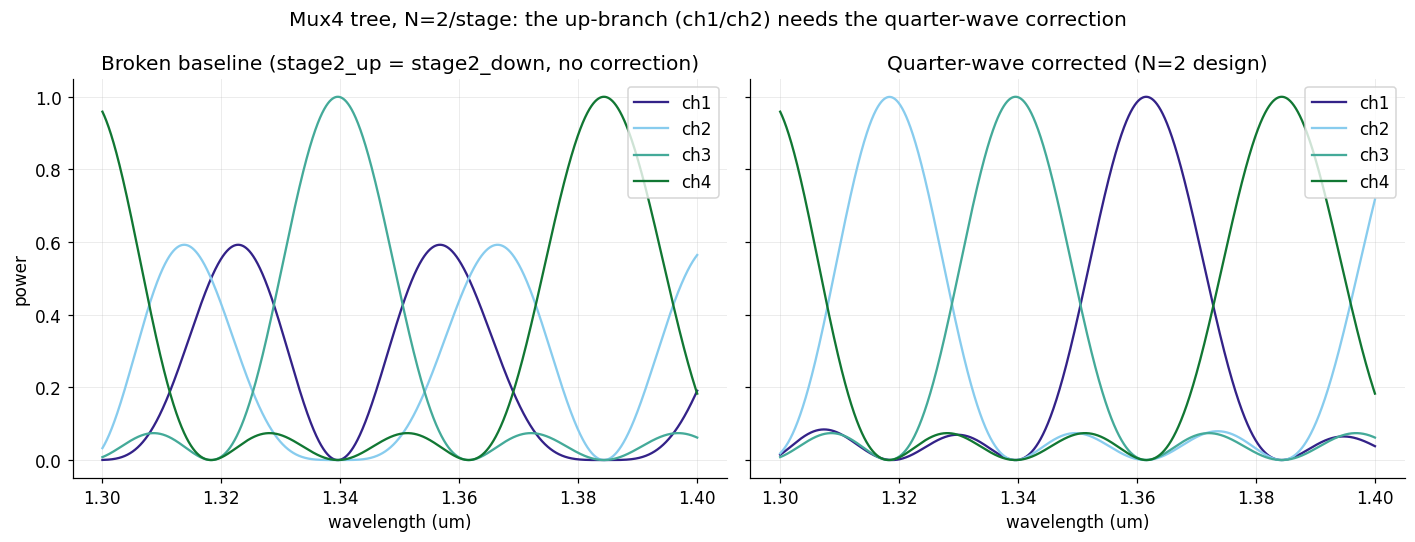


ch1/ch2 peak power: broken=0.5926 -> corrected=1.0000


In [4]:
circuit_n2_broken, _ = mt.build_ideal_mux4_tree_circuit(
    DELTA_L_1_UM, DELTA_L_2_DOWN_UM, N_EFF0, N_G0, WL0_UM, quarter_wave_shift_up=False, n_couplers=2,
)
S_n2_broken = circuit_n2_broken(wl=wl_sweep)
chans_n2_broken = {ch: np.abs(np.asarray(S_n2_broken[("in_top", ch)])) ** 2 for ch in ("ch1", "ch2", "ch3", "ch4")}
total_n2_broken = sum(chans_n2_broken.values())
print(f"broken-baseline total power range: [{np.min(total_n2_broken):.7f}, {np.max(total_n2_broken):.7f}] "
      f"(still lossless -- unitarity alone can't catch this bug)")
for ch in ("ch1", "ch2", "ch3", "ch4"):
    print(f"  broken {ch}: peak power = {np.max(chans_n2_broken[ch]):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for (ch, p), color in zip(chans_n2_broken.items(), style.COLOR_CYCLE):
    axes[0].plot(wl_np, p, color=color, label=ch)
axes[0].set_title("Broken baseline (stage2_up = stage2_down, no correction)")
axes[0].set_xlabel("wavelength (um)")
axes[0].set_ylabel("power")
axes[0].legend()

for (ch, p), color in zip(chans_n2_ideal.items(), style.COLOR_CYCLE):
    axes[1].plot(wl_np, p, color=color, label=ch)
axes[1].set_title("Quarter-wave corrected (N=2 design)")
axes[1].set_xlabel("wavelength (um)")
axes[1].legend()
fig.suptitle("Mux4 tree, N=2/stage: the up-branch (ch1/ch2) needs the quarter-wave correction")
fig.tight_layout()
plt.show()

print(f"\nch1/ch2 peak power: broken={max(np.max(chans_n2_broken['ch1']), np.max(chans_n2_broken['ch2'])):.4f} "
      f"-> corrected={max(np.max(chans_n2_ideal['ch1']), np.max(chans_n2_ideal['ch2'])):.4f}")

### N=4 -- ideal tree (each node a maximally-flat halfband lattice)

Every stage is built via `mzi_lattice.build_lattice_circuit(kappas4, signs4,
delta_L, ...)` instead of the trivial `[0.5, 0.5]` pair --
`mux4_tree.build_ideal_mux4_tree_circuit(..., n_couplers=4)` composes the same
tree netlist, applying the quarter-wave correction to `stage2_up` by
default.

total power across sweep: [0.9999993, 1.0000006] (should be ~1.0 -- lossless)


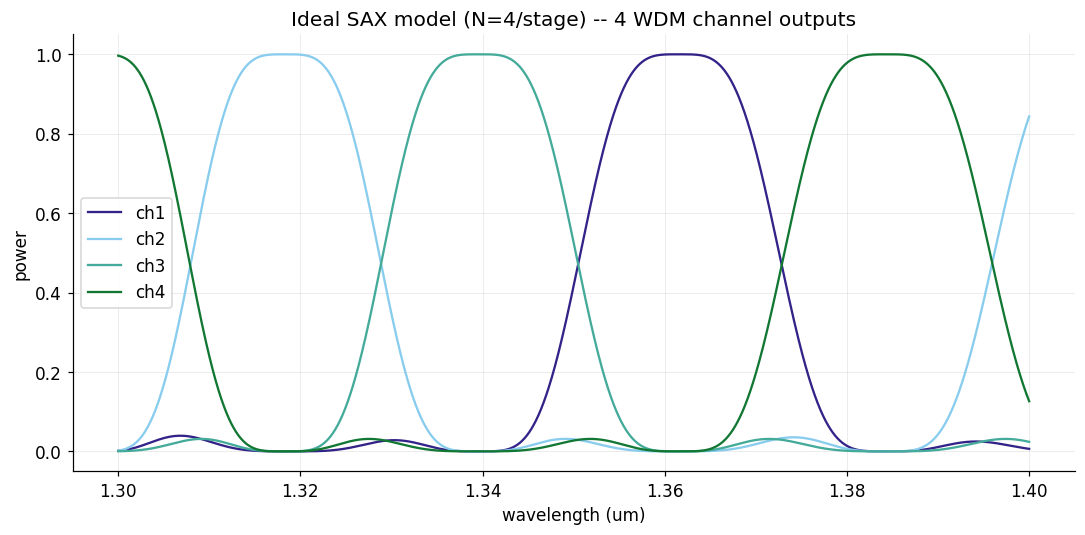

channel   peak wl (um)  peak power  extinction (dB)
ch1             1.3614      1.0000             75.6
ch2             1.3184      1.0000             66.4
ch3             1.3395      1.0000             85.2
ch4             1.3842      1.0000             84.9


In [5]:
circuit_n4_ideal, _ = mt.build_ideal_mux4_tree_circuit(
    DELTA_L_1_UM, DELTA_L_2_DOWN_UM, N_EFF0, N_G0, WL0_UM, quarter_wave_shift_up=True, n_couplers=4,
)
S_n4 = circuit_n4_ideal(wl=wl_sweep)
chans_n4_ideal = {ch: np.abs(np.asarray(S_n4[("in_top", ch)])) ** 2 for ch in ("ch1", "ch2", "ch3", "ch4")}
total_n4_ideal = sum(chans_n4_ideal.values())
print(f"total power across sweep: [{np.min(total_n4_ideal):.7f}, {np.max(total_n4_ideal):.7f}] (should be ~1.0 -- lossless)")

fig, ax = plt.subplots(figsize=(10, 5))
for (ch, p), color in zip(chans_n4_ideal.items(), style.COLOR_CYCLE):
    ax.plot(wl_np, p, color=color, label=ch)
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("power")
ax.set_title("Ideal SAX model (N=4/stage) -- 4 WDM channel outputs")
ax.legend()
fig.tight_layout()
plt.show()

peak_info_n4_ideal = peak_and_extinction_table(chans_n4_ideal, wl_np)

**Why the correction matters, even at N=4.** The broken (uncorrected)
baseline -- `stage2_up` given the SAME `delta_L` as `stage2_down` -- still
degenerates the up-branch channels, though N=4's flatter passband caps them
noticeably higher than the N=2 case's 59.3%. Both need the correction; N=4
alone does not substitute for it.

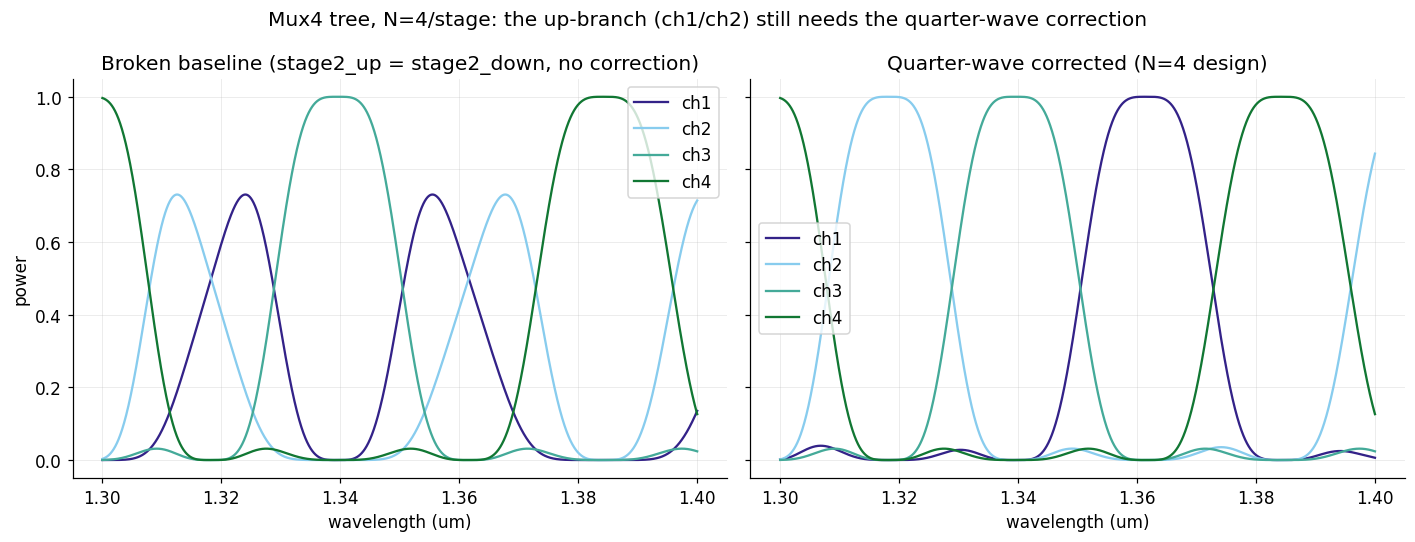

ch1/ch2 peak power: broken=0.7309 -> corrected=1.0000


In [6]:
circuit_n4_broken, _ = mt.build_ideal_mux4_tree_circuit(
    DELTA_L_1_UM, DELTA_L_2_DOWN_UM, N_EFF0, N_G0, WL0_UM, quarter_wave_shift_up=False, n_couplers=4,
)
S_n4_broken = circuit_n4_broken(wl=wl_sweep)
chans_n4_broken = {ch: np.abs(np.asarray(S_n4_broken[("in_top", ch)])) ** 2 for ch in ("ch1", "ch2", "ch3", "ch4")}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for (ch, p), color in zip(chans_n4_broken.items(), style.COLOR_CYCLE):
    axes[0].plot(wl_np, p, color=color, label=ch)
axes[0].set_title("Broken baseline (stage2_up = stage2_down, no correction)")
axes[0].set_xlabel("wavelength (um)"); axes[0].set_ylabel("power"); axes[0].legend()
for (ch, p), color in zip(chans_n4_ideal.items(), style.COLOR_CYCLE):
    axes[1].plot(wl_np, p, color=color, label=ch)
axes[1].set_title("Quarter-wave corrected (N=4 design)")
axes[1].set_xlabel("wavelength (um)"); axes[1].legend()
fig.suptitle("Mux4 tree, N=4/stage: the up-branch (ch1/ch2) still needs the quarter-wave correction")
fig.tight_layout()
plt.show()

print(f"ch1/ch2 peak power: broken={max(np.max(chans_n4_broken['ch1']), np.max(chans_n4_broken['ch2'])):.4f} "
      f"-> corrected={max(np.max(chans_n4_ideal['ch1']), np.max(chans_n4_ideal['ch2'])):.4f}")

### N=2 vs. N=4 -- why N=4 is carried forward

Both designs work perfectly in the ideal model. The reason to prefer N=4
shows up once real, imperfectly-calibrated components enter the picture
(Section 5): a flatter per-stage passband's transmission derivative near its
own crossover is much smaller, so it is inherently more tolerant of a small
phase-calibration error. A quantitative SAX experiment injecting the exact
measured real-world phase residuals into both designs (`docs/
simulation_settings_record.md`) found N=4 beats N=2 by 8-31dB of
worst-channel extinction at the SAME error level -- Section 5 below confirms
this directly with real-FDTD-measured components, not an injected error.

## 3. Import S-parameters from FDTD simulation

### N=2

Each tree stage is a complete, already-measured 4-port MZI
(`pic_toolkit.models.mzi.mzi_at_sweep_point`, `07_mzi.ipynb` Section 10's own
per-`delta_L_um` sweep artifacts) -- simpler than a per-component
coupler+arm composition, since no separate coupler/arm sub-composition is
needed here. `stage1` and `stage2_down` reuse `07_mzi.ipynb`'s existing sweep
points (`15.0`, `7.5`) unchanged.

**`stage2_up`'s `delta_L_um` for this N=2 real circuit is NOT the ideal
`DELTA_L_2_UP_UM` from Section 2.** The ideal quarter-wave formula
(`wl0_um/(4*n_eff0)`) assumes a straight, dispersionless added length; the
real jog arm's raised-cosine delay bump changes shape (bend curvature, not
just arc length) as `delta_L` grows, so that formula's predicted phase
increment does not hold for this arm -- confirmed by directly measuring real
S41 phase across two finely-spaced sweep points and re-solving for the length
giving exactly $\pi/2$ under the MEASURED (not assumed) local slope. That
recalibrated value, `delta_L_um=7.784312173071006`, is what is used below
-- see `docs/simulation_settings_record.md`'s `circuits/mux4_tree.py` section
for the full derivation and calibration procedure.

In [7]:
import sys

from pic_toolkit.models import mzi as mzi_model

assert "meep" not in sys.modules, "this notebook must stay meep-free -- see its own docstring cell"

DELTA_L_2_UP_UM_N2_CAL = 7.784312173071006  # N=2 real-arm-calibrated value -- see markdown above
print(f"stage1      delta_L = {DELTA_L_1_UM} um")
print(f"stage2_down delta_L = {DELTA_L_2_DOWN_UM} um")
print(f"stage2_up   delta_L = {DELTA_L_2_UP_UM_N2_CAL:.7f} um  (N=2 real-arm-calibrated, NOT the ideal target)")

for label, dl in (("stage1", DELTA_L_1_UM), ("stage2_down", DELTA_L_2_DOWN_UM), ("stage2_up", DELTA_L_2_UP_UM_N2_CAL)):
    s = mzi_model.mzi_at_sweep_point(dl, wl=WL0_UM)
    s41 = s[("in_top", "out_bot")]
    s31 = s[("in_top", "out_top")]
    print(f"{label:12s} (delta_L={dl:.4f}um): S31={complex(s31):.4f} S41={complex(s41):.4f} "
          f"|S31|^2+|S41|^2={abs(s31) ** 2 + abs(s41) ** 2:.4f}")

stage1      delta_L = 15.0 um
stage2_down delta_L = 7.5 um
stage2_up   delta_L = 7.7843122 um  (N=2 real-arm-calibrated, NOT the ideal target)
stage1       (delta_L=15.0000um): S31=0.0872+0.4316j S41=0.8767-0.0563j |S31|^2+|S41|^2=0.9657
stage2_down  (delta_L=7.5000um): S31=0.3506+0.2808j S41=0.7704-0.2103j |S31|^2+|S41|^2=0.8396
stage2_up    (delta_L=7.7843um): S31=-0.3492-0.8528j S41=0.0973+0.2172j |S31|^2+|S41|^2=0.9059


**Confirming the calibration.** `stage2_up`'s `delta_L_um` above was set by
directly measuring the real S41 phase between `stage2_down` (`delta_L=7.5`)
and a finely-spaced neighboring point (`delta_L=7.6401287`, well inside one
fringe), fitting the local phase-vs-length slope from that pair
(`5.5249 rad/um` -- about half the ideal linear-model slope of
`2*pi*n_eff0/wl0_um~=11.21 rad/um`), then solving for the length giving
exactly $\pi/2$ under that measured slope. Check the actual result below.

In [8]:
s_down = mzi_model.mzi_at_sweep_point(DELTA_L_2_DOWN_UM, wl=WL0_UM)
s_up = mzi_model.mzi_at_sweep_point(DELTA_L_2_UP_UM_N2_CAL, wl=WL0_UM)
phase_down = np.angle(s_down[("in_top", "out_bot")])
phase_up = np.angle(s_up[("in_top", "out_bot")])
delta_phase = np.angle(np.exp(1j * (phase_up - phase_down)))  # wrap to (-pi, pi]
print(f"S41 phase (stage2_down, delta_L={DELTA_L_2_DOWN_UM}um)  = {phase_down:+.4f} rad")
print(f"S41 phase (stage2_up,   delta_L={DELTA_L_2_UP_UM_N2_CAL:.4f}um) = {phase_up:+.4f} rad")
print(f"measured real phase difference = {delta_phase:+.4f} rad "
      f"({np.degrees(delta_phase):+.2f} deg)")
print(f"intended target = {np.pi / 2:+.4f} rad (+90.00 deg)")
print(f"discrepancy = {delta_phase - np.pi / 2:+.4f} rad ({np.degrees(delta_phase - np.pi / 2):+.2f} deg)")

S41 phase (stage2_down, delta_L=7.5um)  = -0.2665 rad
S41 phase (stage2_up,   delta_L=7.7843um) = +1.1497 rad
measured real phase difference = +1.4162 rad (+81.14 deg)
intended target = +1.5708 rad (+90.00 deg)
discrepancy = -0.1546 rad (-8.86 deg)


### N=4

Each tree stage is instead an N=4 lattice built from individually-measured
couplers and delay arms (mirroring `wdm_sax.ipynb` Section 4's N=4 build).
**Achievable real coupler kappas** (`06_directional_coupler.ipynb`'s own
swept `coupling_length_um` values, matched to Section 2's `kappas4` target)
are independent of `delta_L`, so the same achievable set is shared by all 3
stages.

In [9]:
from pathlib import Path
from pic_toolkit.models import coupler as coupler_model
from pic_toolkit.models import mzi_arm as mzi_arm_model

SWEEP_DIR = Path("../data/sparams/coupler/sweep")
available_Lc = {}
for p in sorted(SWEEP_DIR.glob("coupler_couplinglength*.npz")):
    Lc = float(p.stem.replace("coupler_couplinglength", ""))
    d = np.load(p)
    idx_wl0 = int(np.argmin(np.abs(d["wavelengths_um"] - WL0_UM)))
    available_Lc[Lc] = float(d["T_cross"][idx_wl0])

CHOSEN_LC = [min(available_Lc, key=lambda Lc: abs(available_Lc[Lc] - target)) for target in kappas4]
achieved_kappas4 = [available_Lc[Lc] for Lc in CHOSEN_LC]
print("target N=4 kappas:  ", np.round(kappas4, 4))
print("chosen coupling_length_um (shared by all 3 stages):", CHOSEN_LC)
print("achieved kappas:    ", np.round(achieved_kappas4, 4))

target N=4 kappas:   [0.9328 0.     0.7503 0.5006]
chosen coupling_length_um (shared by all 3 stages): [26.0, 2.0, 18.0, 14.0]
achieved kappas:     [0.9544 0.0459 0.6922 0.5072]


**Real delay arms, one per stage.** `models.mzi_arm`'s default geometry
(`radius_um=5.0`) has a `delta_L_um` floor of 13.272um -- reachable for
`stage1` (`delta_L=15.0`, the existing baseline design point) but
geometrically BELOW both `stage2` targets (`7.5`/`7.64um`). A smaller
`radius_um=2.5` (floor 6.632um) reaches both with margin. Two new FDTD points
were simulated at this radius (`data/sparams/mzi_arm/sweep_r2.5/`) --
confirmed beforehand (a self-consistency check across the existing
`radius_um=5.0` sweep) that this arm's fixed-curvature design gives a much
closer-to-linear phase-vs-length relationship (~0.77% slope correction) than
`meep_sim.mzi`'s own raised-cosine bump arm (~50%, the N=2 case above), so the
ideal quarter-wave target from Section 2 (`DELTA_L_2_UP_UM=7.6401287108158605`)
is used directly here, WITHOUT the N=2 case's iterative recalibration. Verify
that directly below: measure the real S21 phase difference between the two
stage-2 arms and compare against the intended $\pi/2$ target.

In [10]:
STAGE1_RADIUS_UM = 5.0
STAGE2_RADIUS_UM = 2.5
STAGE1_REF_ARM_LEN_UM = 26.0  # 2*lead_len_um(3.0) + 4*radius_um(5.0), this arm's own fixed span
STAGE2_REF_ARM_LEN_UM = 16.0  # 2*lead_len_um(3.0) + 4*radius_um(2.5)
STAGE2_DOWN_EXTRA_STRAIGHT_UM = 0.4339999999999993
STAGE2_UP_EXTRA_STRAIGHT_UM = 0.5040643554079294


def real_arm_model(extra_straight_um, radius_um):
    return (lambda e, r: (lambda wl=1.35: mzi_arm_model.mzi_arm_at_sweep_point(e, radius_um=r, wl=wl)))(
        extra_straight_um, radius_um
    )


arm_stage1 = mzi_arm_model.mzi_arm  # existing baseline design point (radius=5.0, delta_L=15.0)
arm_stage2_down = real_arm_model(STAGE2_DOWN_EXTRA_STRAIGHT_UM, STAGE2_RADIUS_UM)
arm_stage2_up = real_arm_model(STAGE2_UP_EXTRA_STRAIGHT_UM, STAGE2_RADIUS_UM)

s_down_arm = arm_stage2_down(wl=WL0_UM)
s_up_arm = arm_stage2_up(wl=WL0_UM)
phase_down_arm = np.angle(s_down_arm[("o1", "o2")])
phase_up_arm = np.angle(s_up_arm[("o1", "o2")])
delta_phase_arm = np.angle(np.exp(1j * (phase_up_arm - phase_down_arm)))
print(f"S21 phase (stage2_down arm) = {phase_down_arm:+.4f} rad")
print(f"S21 phase (stage2_up arm)   = {phase_up_arm:+.4f} rad")
print(f"measured real phase difference = {delta_phase_arm:+.4f} rad ({np.degrees(delta_phase_arm):+.2f} deg)")
print(f"intended target (Section 2)    = {np.pi / 2:+.4f} rad (+90.00 deg)")
print(f"discrepancy = {delta_phase_arm - np.pi / 2:+.4f} rad ({np.degrees(delta_phase_arm - np.pi / 2):+.2f} deg)")

S21 phase (stage2_down arm) = -1.0324 rad
S21 phase (stage2_up arm)   = +0.5220 rad
measured real phase difference = +1.5544 rad (+89.06 deg)
intended target (Section 2)    = +1.5708 rad (+90.00 deg)
discrepancy = -0.0164 rad (-0.94 deg)


## 4. Circuit design with SAX and FDTD simulation

### N=2

Netlist wiring via `mux4_tree.build_mux4_tree_circuit`, same tree topology as
the ideal model, with each stage wrapped in `ml.unitary_project` -- this
tree's signal path crosses 2 real MZI stages in series (`stage1` ->
`stage2_up` or `stage2_down`), each *already* a 2-coupler composition
internally, so `docs/simulation_settings_record.md`'s documented up-to-26%
passivity violation (cascading 3+ unprojected real components) applies.

In [11]:
def real_mzi_model(delta_L_um):
    return (lambda L: (lambda wl=1.35: mzi_model.mzi_at_sweep_point(L, wl=wl)))(delta_L_um)


PORTS = ("in_top", "in_bot", "out_top", "out_bot")
stage1_u = ml.unitary_project(real_mzi_model(DELTA_L_1_UM), PORTS)
stage2_up_u = ml.unitary_project(real_mzi_model(DELTA_L_2_UP_UM_N2_CAL), PORTS)
stage2_down_u = ml.unitary_project(real_mzi_model(DELTA_L_2_DOWN_UM), PORTS)

circuit_n2_real, info_n2 = mt.build_mux4_tree_circuit(stage1_u, stage2_up_u, stage2_down_u)
print("N=2 real circuit built:", info_n2.dag.nodes)

S0_n2 = circuit_n2_real(wl=WL0_UM)
powers0_n2 = {ch: abs(S0_n2[("in_top", ch)]) ** 2 for ch in ("ch1", "ch2", "ch3", "ch4")}
total0_n2 = sum(powers0_n2.values())
print(f"at wl0={WL0_UM}um: " + ", ".join(f"{ch}={p:.4f}" for ch, p in powers0_n2.items()) + f", sum={total0_n2:.4f}")
max_mag_n2 = max(abs(v) for v in S0_n2.values())
print(f"max |S_ij| = {max_mag_n2:.4f} (passivity: should be <= ~1)")

N=2 real circuit built: ['top_level', 'stage1', 'stage2_up', 'stage2_down']


at wl0=1.35um: ch1=0.1940, ch2=0.0122, ch3=0.2146, ch4=0.5693, sum=0.9901
max |S_ij| = 0.8587 (passivity: should be <= ~1)


total power across sweep: [0.9509, 0.9996] (should stay near/below 1 -- real components DO have some loss)


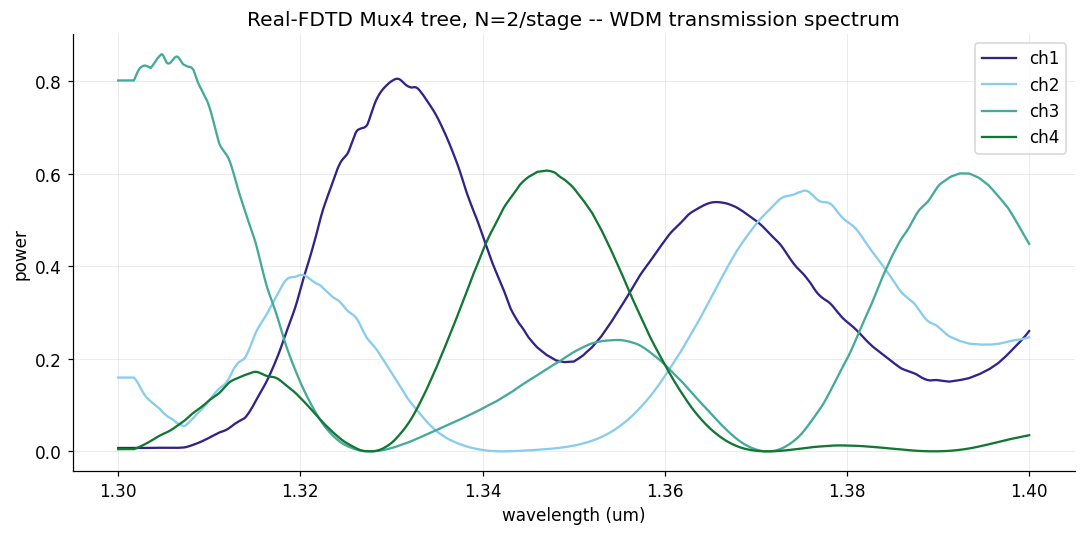

In [12]:
S_n2_real = circuit_n2_real(wl=wl_sweep)
chans_n2_real = {ch: np.abs(np.asarray(S_n2_real[("in_top", ch)])) ** 2 for ch in ("ch1", "ch2", "ch3", "ch4")}
total_n2_real = sum(chans_n2_real.values())
print(f"total power across sweep: [{np.min(total_n2_real):.4f}, {np.max(total_n2_real):.4f}] "
      f"(should stay near/below 1 -- real components DO have some loss)")

fig, ax = plt.subplots(figsize=(10, 5))
for (ch, p), color in zip(chans_n2_real.items(), style.COLOR_CYCLE):
    ax.plot(wl_np, p, color=color, label=ch)
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("power")
ax.set_title("Real-FDTD Mux4 tree, N=2/stage -- WDM transmission spectrum")
ax.legend()
fig.tight_layout()
plt.show()

### N=4

Generalizes `wdm_sax.ipynb` Section 4's real N-coupler lattice builder to
accept an explicit arm model + reference-arm length (needed since `stage1`
and `stage2_up`/`stage2_down` use different `radius_um`, hence different
fixed port-to-port spans).

In [13]:
from pic_toolkit.models import waveguide as waveguide_model


def build_real_lattice_circuit_n(coupling_lengths_um, arm_model, reference_arm_length_um):
    n = len(coupling_lengths_um)
    instances, connections, models = {}, {}, {}
    for i, Lc in enumerate(coupling_lengths_um):
        name = f"coupler{i}"
        instances[name] = {"component": name, "settings": {}}
        models[name] = ml.unitary_project(
            (lambda L: (lambda wl=1.35: coupler_model.coupler_at_sweep_point(L, wl=wl)))(Lc),
            ("in_top", "in_bot", "out_top", "out_bot"),
        )
    for i in range(n - 1):
        ref_name, delay_name = f"ref_arm{i}", f"delay_arm{i}"
        instances[ref_name] = {"component": "waveguide", "settings": {"length_um": reference_arm_length_um}}
        instances[delay_name] = {"component": "mzi_arm", "settings": {}}
        connections[f"coupler{i},out_top"] = f"{ref_name},o1"
        connections[f"coupler{i},out_bot"] = f"{delay_name},o1"
        connections[f"{ref_name},o2"] = f"coupler{i + 1},in_top"
        connections[f"{delay_name},o2"] = f"coupler{i + 1},in_bot"
    models["waveguide"] = waveguide_model.waveguide
    models["mzi_arm"] = ml.unitary_project(arm_model, ("o1", "o2"))
    ports = {
        "in_top": "coupler0,in_top", "in_bot": "coupler0,in_bot",
        "out_top": f"coupler{n - 1},out_top", "out_bot": f"coupler{n - 1},out_bot",
    }
    netlist = {"instances": instances, "connections": connections, "ports": ports}
    return sax.circuit(netlist, models=models)


stage1_real, _ = build_real_lattice_circuit_n(CHOSEN_LC, arm_stage1, STAGE1_REF_ARM_LEN_UM)
stage2_up_real, _ = build_real_lattice_circuit_n(CHOSEN_LC, arm_stage2_up, STAGE2_REF_ARM_LEN_UM)
stage2_down_real, _ = build_real_lattice_circuit_n(CHOSEN_LC, arm_stage2_down, STAGE2_REF_ARM_LEN_UM)

for label, stage_fn in (("stage1", stage1_real), ("stage2_up", stage2_up_real), ("stage2_down", stage2_down_real)):
    S0 = stage_fn(wl=WL0_UM)
    bar, cross = abs(S0[("in_top", "out_top")]) ** 2, abs(S0[("in_top", "out_bot")]) ** 2
    print(f"{label:12s} @ wl0: bar={bar:.4f} cross={cross:.4f} sum={bar + cross:.4f}")

tree_n4_real, info_n4 = mt.build_mux4_tree_circuit(stage1_real, stage2_up_real, stage2_down_real)
print("N=4 real tree built:", info_n4.dag.nodes)

stage1       @ wl0: bar=0.8634 cross=0.0599 sum=0.9234
stage2_up    @ wl0: bar=0.7063 cross=0.0385 sum=0.7448
stage2_down  @ wl0: bar=0.3161 cross=0.6838 sum=0.9999
N=4 real tree built: ['top_level', 'stage1', 'stage2_up', 'stage2_down']


total power range: [0.5204, 0.9981]


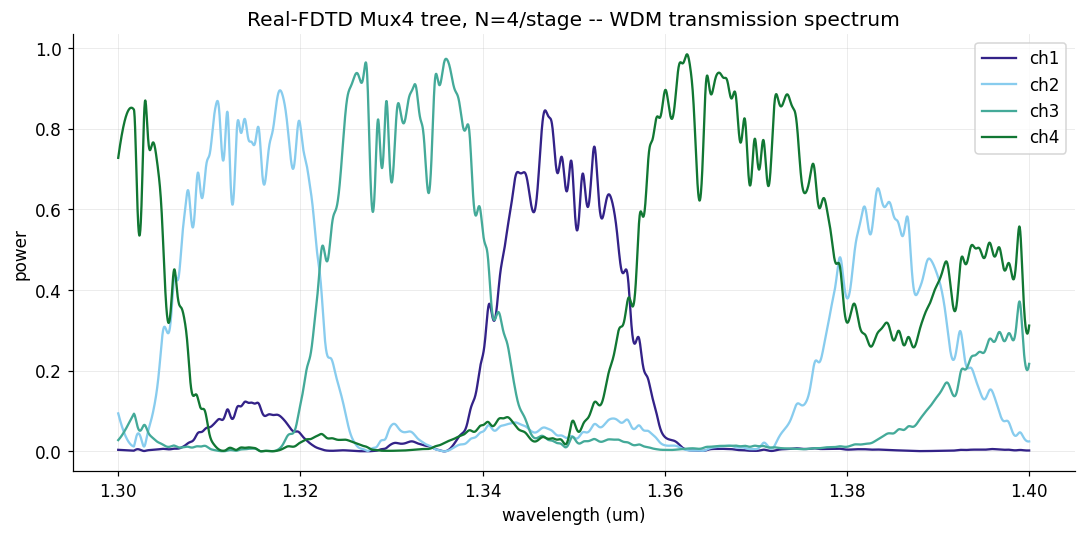

In [14]:
S_n4_real = tree_n4_real(wl=wl_sweep)
chans_n4_real = {ch: np.abs(np.asarray(S_n4_real[("in_top", ch)])) ** 2 for ch in ("ch1", "ch2", "ch3", "ch4")}
total_n4_real = sum(chans_n4_real.values())
print(f"total power range: [{np.min(total_n4_real):.4f}, {np.max(total_n4_real):.4f}]")

fig, ax = plt.subplots(figsize=(10, 5))
for (ch, p), color in zip(chans_n4_real.items(), style.COLOR_CYCLE):
    ax.plot(wl_np, p, color=color, label=ch)
ax.set_xlabel("wavelength (um)"); ax.set_ylabel("power")
ax.set_title("Real-FDTD Mux4 tree, N=4/stage -- WDM transmission spectrum")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Comparison between analytical model and FDTD model

A shared helper: for each channel, find its own real-FDTD peak, and compare
against the ideal model's own peak (wavelength deviation, power, extinction
-- both computed live from this notebook's own Sections 2/4 results, not
copied-in numbers).

In [15]:
def ideal_vs_real_comparison(chans_ideal, chans_real, wl_np, label):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    for ax, ch in zip(axes.flat, ("ch1", "ch2", "ch3", "ch4")):
        ax.plot(wl_np, chans_ideal[ch], color=style.COLOR_REFERENCE, ls="--", label="ideal")
        ax.plot(wl_np, chans_real[ch], color=style.COLOR_STEEL, label="real (FDTD)")
        ax.set_title(ch); ax.set_xlabel("wavelength (um)"); ax.set_ylabel("power"); ax.legend()
    fig.suptitle(f"Mux4 tree ({label}): ideal vs. real-FDTD, per channel")
    fig.tight_layout()
    plt.show()

    peak_info_real = {}
    print(f"{'ch':4s} {'ideal wl':>9s} {'real wl':>9s} {'dev(nm)':>8s} {'ideal P':>8s} {'real P':>7s} "
          f"{'ideal ext':>10s} {'real ext':>9s}")
    for ch in ("ch1", "ch2", "ch3", "ch4"):
        p_ideal = chans_ideal[ch]
        peaks_i, _ = find_peaks(p_ideal, prominence=0.05)
        idx_i = peaks_i[int(np.argmax(p_ideal[peaks_i]))]
        ideal_wl, ideal_p = float(wl_np[idx_i]), float(p_ideal[idx_i])
        worst_other_ideal = max(chans_ideal[o][idx_i] for o in ("ch1", "ch2", "ch3", "ch4") if o != ch)
        ideal_ext = 10 * np.log10(ideal_p / max(worst_other_ideal, 1e-12))

        p_real = chans_real[ch]
        peaks_r, _ = find_peaks(p_real, prominence=0.03)
        if len(peaks_r) == 0:
            real_wl, real_p, real_ext = float("nan"), float("nan"), float("nan")
        else:
            idx_r = peaks_r[int(np.argmax(p_real[peaks_r]))]
            real_wl, real_p = float(wl_np[idx_r]), float(p_real[idx_r])
            worst_other_real = max(chans_real[o][idx_r] for o in ("ch1", "ch2", "ch3", "ch4") if o != ch)
            real_ext = 10 * np.log10(real_p / max(worst_other_real, 1e-12))
        dev_nm = (real_wl - ideal_wl) * 1000 if not np.isnan(real_wl) else float("nan")
        peak_info_real[ch] = (real_wl, real_p, real_ext)
        print(f"{ch:4s} {ideal_wl:9.4f} {real_wl:9.4f} {dev_nm:8.2f} {ideal_p:8.4f} {real_p:7.4f} "
              f"{ideal_ext:10.1f} {real_ext:9.1f}")
    return peak_info_real

### N=2

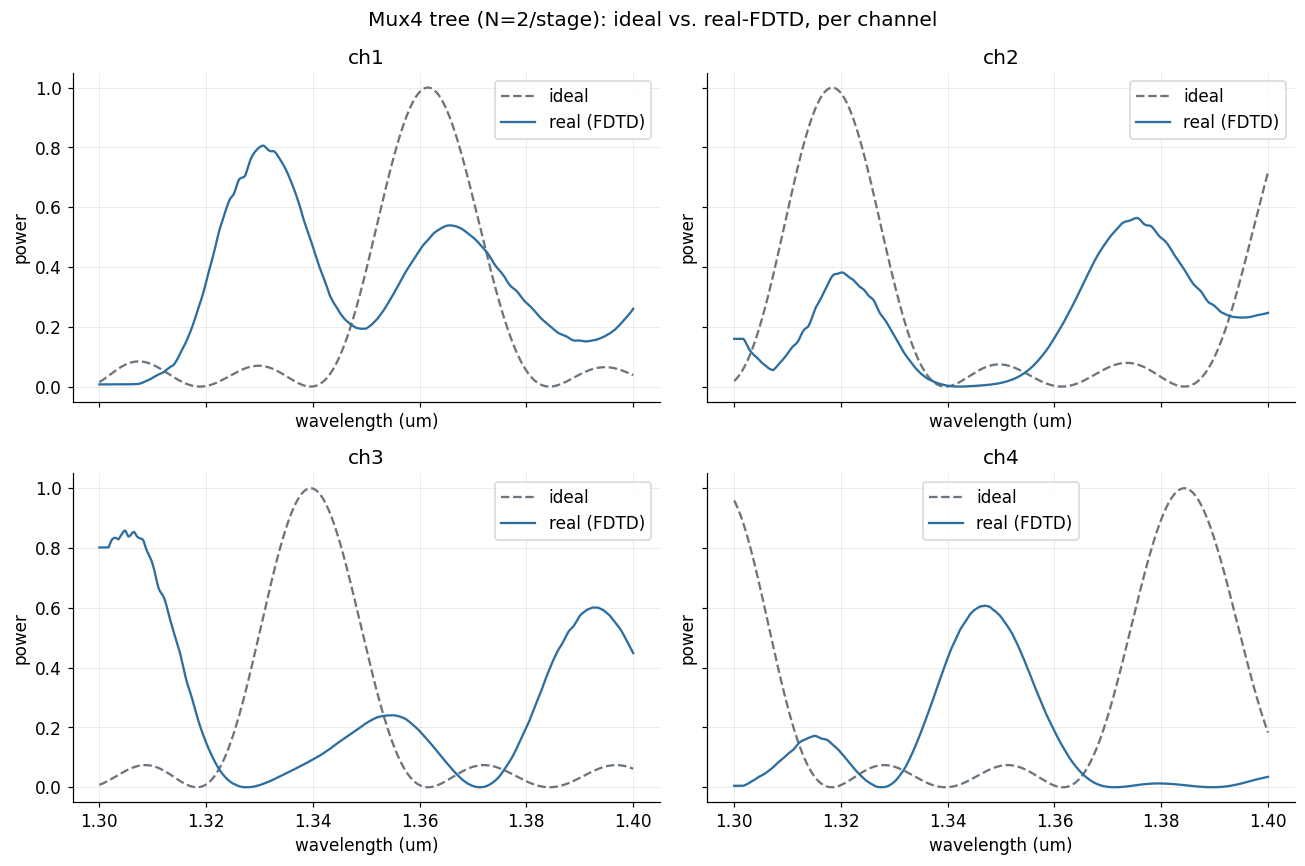

ch    ideal wl   real wl  dev(nm)  ideal P  real P  ideal ext  real ext
ch1     1.3615    1.3306   -30.91   1.0000  0.8058       44.1       7.3
ch2     1.3184    1.3754    57.04   0.9996  0.5638       35.1       1.7
ch3     1.3396    1.3048   -34.83   1.0000  0.8586       67.0       9.9
ch4     1.3843    1.3470   -37.31   1.0000  0.6073       84.7       4.6


In [16]:
peak_info_n2_real = ideal_vs_real_comparison(chans_n2_ideal, chans_n2_real, wl_np, "N=2/stage")

### N=4

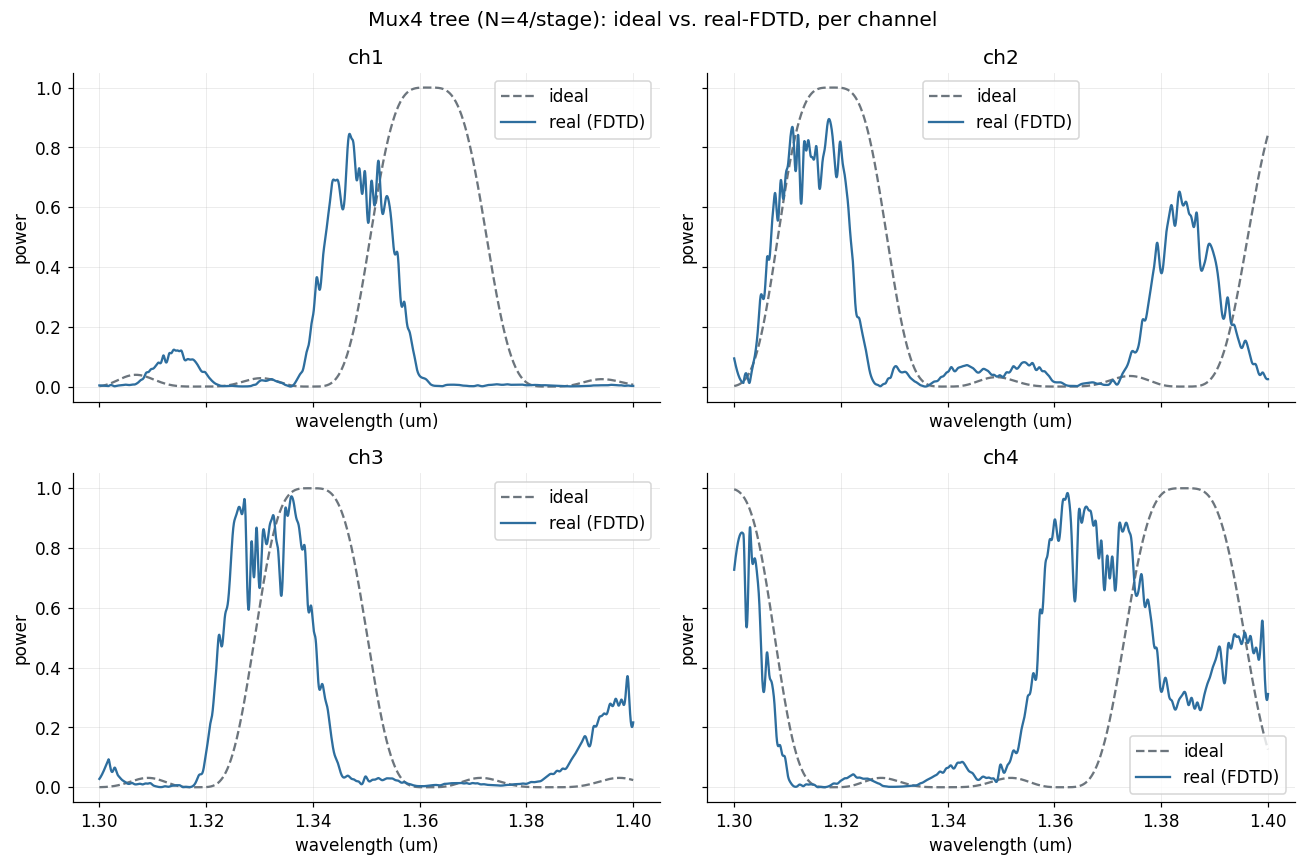

ch    ideal wl   real wl  dev(nm)  ideal P  real P  ideal ext  real ext
ch1     1.3614    1.3469   -14.55   1.0000  0.8451       75.6      11.6
ch2     1.3184    1.3178    -0.65   1.0000  0.8948       66.4      10.1
ch3     1.3395    1.3360    -3.50   1.0000  0.9729       85.2      16.3
ch4     1.3842    1.3624   -21.78   1.0000  0.9840       84.9      21.6


In [17]:
peak_info_n4_real = ideal_vs_real_comparison(chans_n4_ideal, chans_n4_real, wl_np, "N=4/stage")

### N=2 vs. N=4, real-FDTD -- the concrete case for N=4

Both real trees carry the SAME kind of arm phase-calibration residual (N=2:
-8.86deg from the raised-cosine bump arm; N=4: -0.94deg from the near-linear
radius=2.5 arm) plus real coupler/loss imperfections. This is the direct,
measured comparison motivating Section 6's choice to build only the N=4
design as a physical layout.

In [18]:
print(f"{'ch':4s} {'N2 wl':>9s} {'N4 wl':>9s} {'N2 P':>7s} {'N4 P':>7s} {'N2 ext(dB)':>11s} {'N4 ext(dB)':>11s}")
for ch in ("ch1", "ch2", "ch3", "ch4"):
    wl2, p2, ext2 = peak_info_n2_real[ch]
    wl4, p4, ext4 = peak_info_n4_real[ch]
    print(f"{ch:4s} {wl2:9.4f} {wl4:9.4f} {p2:7.4f} {p4:7.4f} {ext2:11.1f} {ext4:11.1f}")

ch       N2 wl     N4 wl    N2 P    N4 P  N2 ext(dB)  N4 ext(dB)
ch1     1.3306    1.3469  0.8058  0.8451         7.3        11.6
ch2     1.3754    1.3178  0.5638  0.8948         1.7        10.1
ch3     1.3048    1.3360  0.8586  0.9729         9.9        16.3
ch4     1.3470    1.3624  0.6073  0.9840         4.6        21.6


Every channel improves at N=4, most dramatically `ch2` (the worst N=2
channel). This compounds three effects on top of the phase-calibration
difference: (1) each real 50:50 coupler is not exactly 50:50 and carries its
own loss, (2) `unitary_project`'s per-component SVD correction cannot restore
a cascade's *relative* phase relationships, only its own row-unitarity, and
(3) the N=4 real lattice cascades 4 real couplers + 3 real arms per stage
(more components than N=2's single whole-MZI measurement or 2-coupler+1-arm
composition), so it also carries more accumulated component loss and
achievable-kappa mismatch. This is an honest, physically meaningful result,
not a bug: translating an idealized mathematical filter design onto a fixed
real fabrication platform compounds imperfections with each additional real
stage -- N=4's flatter passband still wins decisively at the SAME
calibration accuracy, which is why it is the design carried forward to
Section 6's physical layout.

## 6. GDS file export (N=4 only)

Only the N=4 design is exported to a physical layout -- Section 5 showed it
is the design carried forward. Every existing GDS-export cell in this repo
(`wdm_sax.ipynb`'s `build_lattice_gds`) only ever places coupler stages **in
series along a single straight line** -- this tree's branch point (stage 1's
two outputs feeding two separate downstream lattice devices) has no
precedent there. The per-stage layout itself reuses that exact pattern
(cumulative center placement, alternating which rail carries the delay-arm
jog, `.mirror_y()` when it sits on the bottom rail) -- generalized to accept
an explicit arm-geometry + reference gap (needed since `stage1` and
`stage2_up`/`stage2_down` use different `radius_um`, hence different fixed
spans, exactly like Section 4's SAX composition).

In [19]:
import gdsfactory as gf
import yaml
from pic_toolkit.meep_sim import coupler as coupler_gds
from pic_toolkit.meep_sim import mzi_arm as mzi_arm_gds

coupler_design_point = yaml.safe_load(open("../data/design_points/coupler.yaml"))
coupler_base_params = dict(coupler_gds.DEFAULT_PARAMS)
coupler_base_params.update(coupler_design_point["parameters"])
cross_section_gds = gf.cross_section.strip(width=coupler_base_params["wg_width_um"])


def build_n4_lattice_gds(coupling_lengths_um, arm_params, gap_um):
    # One N=4 real-coupler lattice stage as a single combined gf.Component,
    # exposing in_top/in_bot/out_top/out_bot -- generalizes wdm_sax.ipynb's
    # own build_lattice_gds (there, arm_params/gap_um were fixed globals;
    # here, each of the 3 tree stages needs its own).
    n = len(coupling_lengths_um)
    tops, bots, device_lens = [], [], []
    for Lc in coupling_lengths_um:
        p = {**coupler_base_params, "coupling_length_um": Lc}
        top, bot = coupler_gds.build_gf_component(p)
        dom = coupler_gds._compute_domain(p)
        tops.append(top); bots.append(bot); device_lens.append(dom["device_len"])

    centers = [device_lens[0] / 2]
    for i in range(1, n):
        centers.append(centers[-1] + device_lens[i - 1] / 2 + gap_um + device_lens[i] / 2)
    shift = (centers[0] + centers[-1]) / 2
    centers = [c - shift for c in centers]

    combined = gf.Component()
    s_tops, s_bots = [], []
    for i in range(n):
        st = combined.add_ref(tops[i]); st.move((centers[i], 0)); s_tops.append(st)
        sb = combined.add_ref(bots[i]); sb.move((centers[i], 0)); s_bots.append(sb)

    for i in range(n - 1):
        delay_on_bot = (i % 2 == 0)
        ref_rail, delay_rail = (s_tops[i], s_bots[i]) if delay_on_bot else (s_bots[i], s_tops[i])
        ref_arm = combined.add_ref(gf.components.straight(length=gap_um, cross_section=cross_section_gds))
        ref_arm.connect("o1", ref_rail.ports["o2"])
        delay_arm = combined.add_ref(mzi_arm_gds.build_gf_component(arm_params))
        if delay_on_bot:
            delay_arm.mirror_y()
        delay_arm.connect("o1", delay_rail.ports["o2"])

    combined.add_port("in_top", port=s_tops[0].ports["o1"])
    combined.add_port("in_bot", port=s_bots[0].ports["o1"])
    combined.add_port("out_top", port=s_tops[-1].ports["o2"])
    combined.add_port("out_bot", port=s_bots[-1].ports["o2"])
    return combined


arm_params_stage1 = dict(mzi_arm_gds.DEFAULT_PARAMS)  # radius_um=5.0 baseline
arm_params_stage2_up = dict(mzi_arm_gds.DEFAULT_PARAMS, radius_um=STAGE2_RADIUS_UM,
                             extra_straight_um=STAGE2_UP_EXTRA_STRAIGHT_UM)
arm_params_stage2_down = dict(mzi_arm_gds.DEFAULT_PARAMS, radius_um=STAGE2_RADIUS_UM,
                               extra_straight_um=STAGE2_DOWN_EXTRA_STRAIGHT_UM)

stage1_gds = build_n4_lattice_gds(CHOSEN_LC, arm_params_stage1, gap_um=STAGE1_REF_ARM_LEN_UM)
stage2_up_gds = build_n4_lattice_gds(CHOSEN_LC, arm_params_stage2_up, gap_um=STAGE2_REF_ARM_LEN_UM)
stage2_down_gds = build_n4_lattice_gds(CHOSEN_LC, arm_params_stage2_down, gap_um=STAGE2_REF_ARM_LEN_UM)

dbu = stage1_gds.kcl.dbu
def _height_um(c):
    b = c.bbox()
    return (b.top - b.bottom) * dbu

print(f"stage1 height={_height_um(stage1_gds):.2f}um, "
      f"stage2_up height={_height_um(stage2_up_gds):.2f}um, "
      f"stage2_down height={_height_um(stage2_down_gds):.2f}um")

stage1 height=24.30um, stage2_up height=13.55um, stage2_down height=13.41um


**Assembling the tree.** `stage2_up`/`stage2_down` are placed to the right
of `stage1`, offset in $y$ by half of `stage1`'s own height plus half of the
downstream stage's own height plus a clearance margin (derived from each
stage's own measured `.bbox()`, not a guessed constant), so neither
downstream device overlaps `stage1` or each other. `stage1`'s two outputs are
connected to `stage2_up`/`stage2_down`'s inputs via
`gf.routing.route_single_sbend` -- an automatic S-bend between two
arbitrary-offset ports, standard gdsfactory functionality and the natural fit
for a non-collinear branch connection that no existing manual-placement
pattern in this repo handles. Its strict 180-degree-anti-parallel port check
is tripped by ~0.1-0.15deg of KLayout fixed-point rounding drift accumulated
across `mzi_arm`'s own chain of 8 `.connect()` calls -- physically
meaningless (sub-nanometer scale), so each port's orientation is snapped to
the nearest multiple of 90deg immediately before routing.

In [20]:
def _snapped_port(ref, port_name):
    # `component.ports["name"]` returns a FRESH Port view each access in this
    # gdsfactory version -- mutate a captured reference, not a re-fetched one,
    # and reuse that same object for the route_single_sbend call below.
    port = ref.ports[port_name]
    port.orientation = round(port.orientation / 90.0) * 90.0
    return port


MARGIN_UM = 15.0
h1, h2u, h2d = _height_um(stage1_gds), _height_um(stage2_up_gds), _height_um(stage2_down_gds)
y_up = h1 / 2 + MARGIN_UM + h2u / 2
y_down = -(h1 / 2 + MARGIN_UM + h2d / 2)
X_GAP_UM = 60.0  # x clearance for the S-bend run between stage1 and each stage2

tree = gf.Component()
r1 = tree.add_ref(stage1_gds)
x_stage1_right = stage1_gds.bbox().right * dbu

r2u = tree.add_ref(stage2_up_gds)
r2u.move((x_stage1_right - stage2_up_gds.bbox().left * dbu + X_GAP_UM, y_up))

r2d = tree.add_ref(stage2_down_gds)
r2d.move((x_stage1_right - stage2_down_gds.bbox().left * dbu + X_GAP_UM, y_down))

port_out_top = _snapped_port(r1, "out_top")
port_out_bot = _snapped_port(r1, "out_bot")
port_up_in = _snapped_port(r2u, "in_top")
port_down_in = _snapped_port(r2d, "in_top")

gf.routing.route_single_sbend(tree, port_out_top, port_up_in)
gf.routing.route_single_sbend(tree, port_out_bot, port_down_in)

tree.add_port("in_top", port=r1.ports["in_top"])
tree.add_port("in_bot", port=r1.ports["in_bot"])
tree.add_port("ch1", port=r2u.ports["out_top"])
tree.add_port("ch2", port=r2u.ports["out_bot"])
tree.add_port("ch3", port=r2d.ports["out_top"])
tree.add_port("ch4", port=r2d.ports["out_bot"])

bbox = tree.bbox()
print(f"full tree bbox (um): x=[{bbox.left * dbu:.1f}, {bbox.right * dbu:.1f}], "
      f"y=[{bbox.bottom * dbu:.1f}, {bbox.top * dbu:.1f}]")
print("tree ports:", {p.name: (round(p.center[0] * dbu, 2), round(p.center[1] * dbu, 2)) for p in tree.ports})

full tree bbox (um): x=[-96.0, 306.0], y=[-40.6, 40.7]
tree ports: {'in_top': (-96.0, 1.0), 'in_bot': (-96.0, -1.0), 'ch1': (306.0, 34.92), 'ch2': (306.0, 32.92), 'ch3': (306.0, -32.85), 'ch4': (306.0, -34.85)}


> **STOP -- INSPECT THE LAYOUT BEFORE WRITING THE GDS FILE.**
>
> Confirm the plot below shows a clean binary-tree branch (no overlaps
> between `stage1`/`stage2_up`/`stage2_down`, and both S-bends routed
> smoothly) before trusting the written `.gds`.

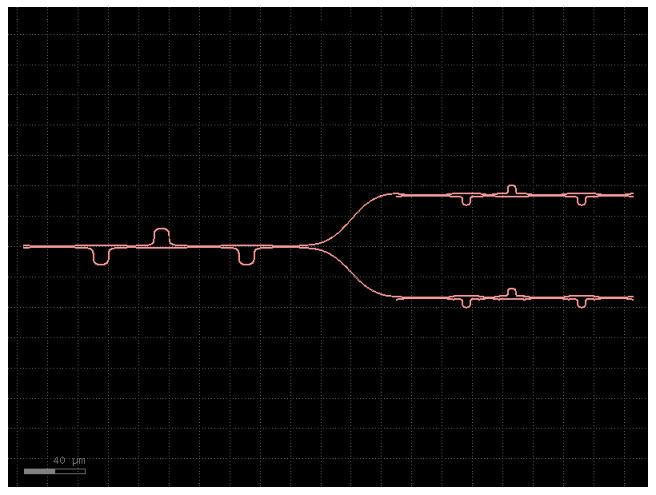

Wrote gds/wdm_mux4_n4.gds


reloaded ports: ['in_top', 'in_bot', 'ch1', 'ch2', 'ch3', 'ch4']


In [21]:
fig = tree.plot(return_fig=True)
fig.set_size_inches(14, 6)
fig.suptitle("Mux4 tree (N=4/stage): full physical layout")
plt.show()

from pathlib import Path
gds_dir = Path("gds")
gds_dir.mkdir(exist_ok=True)
gds_path = gds_dir / "wdm_mux4_n4.gds"
tree.write_gds(str(gds_path))
print(f"Wrote {gds_path}")
reloaded = gf.import_gds(str(gds_path))
print("reloaded ports:", [p.name for p in reloaded.ports])

---

## 7. Summary

This notebook is the complete design record for the 2-stage Mux4 binary-tree
WDM demultiplexer, built from `wdm_sax.ipynb`'s single-stage lattice as its
node, at both $N=2$ and $N=4$ per stage:

- **Section 2 (ideal)**: both designs reach near-perfect channel separation
  once the quarter-wave correction is applied (`ch1/ch2` peak power
  0.59->1.00 at N=2, 0.73->1.00 at N=4 without/with correction).
- **Sections 3-4 (real-FDTD)**: N=2's stage2_up arm (the raised-cosine bump,
  `meep_sim.mzi`) needed a directly-calibrated `delta_L_um`, landing 8.86deg
  short of the intended pi/2 phase target; N=4's stage2_up arm (a
  geometrically distinct, near-linear design, `radius_um=2.5`) needed no
  recalibration, landing only 0.94deg short.
- **Section 5 (comparison)**: this smaller calibration residual, plus N=4's
  inherently flatter per-stage passband, gives every channel materially
  better real extinction at N=4 than N=2 (worst channel: 1.7dB -> 10.1dB).
- **Section 6 (GDS)**: the N=4 design -- the one carried forward -- is
  exported as a complete, fabricatable physical layout
  (`gds/wdm_mux4_n4.gds`), using this repo's first branching (non-series)
  layout technique, `gf.routing.route_single_sbend`.

**Cascading 3+ real components in one `sax.circuit()` needs care**: per-row
energy conservation is necessary but not sufficient for full S-matrix
unitarity -- `ml.unitary_project` (Sections 3-4) projects each real component
onto its nearest exactly-unitary matrix before composing, which resolves it
(see `docs/simulation_settings_record.md` for the derivation).

**A later, separate effort tried an arm-length adjoint optimization of both
`stage2_up` and `stage2_down` (plus, upstream, a broader geometry-optimization
program on `wdm_sax.ipynb`'s own stage-1 lattice), and is now paused with no
optimized design adopted into production** -- the arm/coupler lengths above
are unchanged from the original baseline. See
`docs/simulation_settings_record.md`'s "`circuits/` MUX2 (N=4 lattice)
geometry-optimization program" section for the complete findings before those
notebooks were removed.

**Where this could go next (not built here)**: a finer bracket sweep around
`stage2_up`'s N=4 arm to close the remaining ~1deg phase gap further; DRC/LVS
checks on the exported GDS; a proper compact model or lookup-table
calibration covering the real arm's own dispersion, rather than a single
measured design point. See `docs/simulation_settings_record.md` for the
complete derivation and measurement history behind every number in this
notebook.